In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
df = pd.read_csv('/home/hungday/Documents/python/Data-visualization-/data/ibtracs-2000.csv')
df.shape

/tmp/ipykernel_8822/4108068590.py:1: DtypeWarning: Columns (1,2,8,9,14,161,162) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/home/hungday/Documents/python/Data-visualization-/data/ibtracs-2000.csv')


(8933, 163)

In [6]:
cyclone_df = pd.DataFrame(df.iloc[1:, [0,6,8,9]]).reset_index(drop=True)
cyclone_df.head()

,SID,ISO_TIME,LAT,LON
0,1999231N20266,1999-08-19 06:00:00,19.6000,-94.6000
1,1999231N20266,1999-08-19 09:00:00,19.6500,-94.6000
2,1999231N20266,1999-08-19 12:00:00,19.7000,-94.6000
3,1999231N20266,1999-08-19 15:00:00,19.7575,-94.6500
4,1999231N20266,1999-08-19 18:00:00,19.8000,-94.7000


In [13]:
def is_in_circle(lat, lon, center_lat, center_lon, radius_km):
    # Approximate 1 degree of latitude and longitude in km (for small distances)
    km_per_deg_lat = 111.32
    km_per_deg_lon = 40075 * np.cos(np.radians(center_lat)) / 360
    
    # Compute distance from the center
    distance_lat = (lat - center_lat) * km_per_deg_lat
    distance_lon = (lon - center_lon) * km_per_deg_lon
    distance = np.sqrt(distance_lat**2 + distance_lon**2)
    
    # Check if the point is within the radius
    return distance <= radius_km

In [7]:
twokcondition = [x[:4] == "2000" for x in cyclone_df["ISO_TIME"]]

In [8]:
cyclone2k_df = cyclone_df[twokcondition].reset_index(drop=True)

In [9]:
cyclone2k_df["LAT"] = cyclone2k_df["LAT"].astype(float)
cyclone2k_df["LON"] = cyclone2k_df["LON"].astype(float)

In [10]:
min_lat, max_lat = 8, 24
min_lon, max_lon = 102, 110

In [11]:
vn_condition = (cyclone2k_df["LAT"] >= min_lat) & (cyclone2k_df["LAT"] <= max_lat) & (cyclone2k_df["LON"] >= min_lon) & (cyclone2k_df["LON"] <= max_lon)

In [12]:
vn_cyclone2k_df = cyclone2k_df[vn_condition].reset_index(drop=True)

vn_cyclone2k_df["ISO_TIME"] = [date[5:11] for date in vn_cyclone2k_df["ISO_TIME"]]

vn_cyclone2k_df.drop_duplicates(subset="ISO_TIME", keep="first", inplace=True)

In [14]:
llcrnrlat, urcrnrlat = 8, 24   # Latitude range
llcrnrlon, urcrnrlon = 102, 110  # Longitude range


# Create a grid of latitude and longitude values
lat_values = np.linspace(llcrnrlat, urcrnrlat, (urcrnrlat-llcrnrlat)*20)
lon_values = np.linspace(llcrnrlon, urcrnrlon, (urcrnrlon-llcrnrlon)*20)
lat_grid, lon_grid = np.meshgrid(lat_values, lon_values)

# Initialize an overlap counter grid
overlap_count = np.zeros(lat_grid.shape)

# For each circle, check which points in the grid fall inside the circle
for center_lat, center_lon in zip(vn_cyclone2k_df["LAT"], vn_cyclone2k_df["LON"]):
    for i in range(lat_grid.shape[0]):
        for j in range(lat_grid.shape[1]):
            if is_in_circle(lat_grid[i, j], lon_grid[i, j], center_lat, center_lon, 250):
                overlap_count[i, j] += 1

In [15]:
from numpy import *
from mpl_toolkits.basemap import Basemap

/home/hungday/anaconda3/envs/dataVis/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


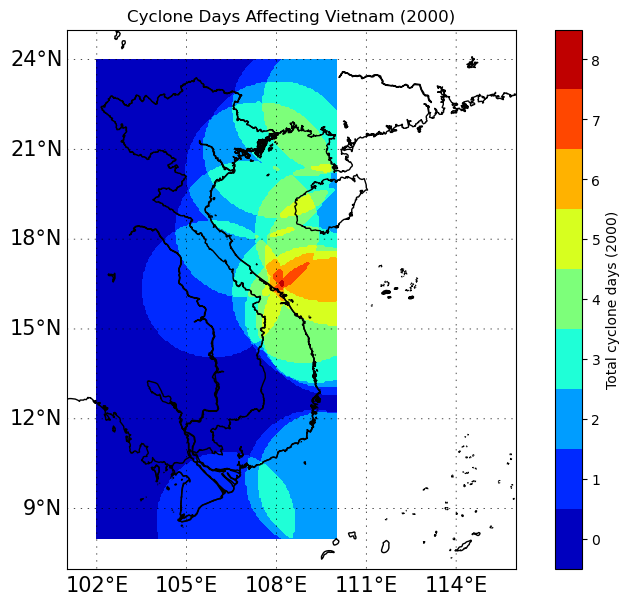

In [18]:
fig = plt.figure(figsize=(10,7))

#basemap setting
lon_min = 101
lon_max = 116
lat_min = 7
lat_max = 25

map2 = Basemap(projection='merc',
                llcrnrlon=lon_min, #lower left corner longtitude
                llcrnrlat=lat_min, #lower left corner lattitude
                urcrnrlon=lon_max, #upper right corner longtitude
                urcrnrlat=lat_max, #upper right corner lattitude
                resolution='i',epsg=4326)

#draw the lat and lon
parallels = arange(-90.,150, around((lat_max-lat_min)/6, decimals=1)) 	#lat
meridians = arange(0.,180., around((lon_max-lon_min)/5, decimals=1))
map2.drawparallels(parallels,linewidth=0.5,dashes=[2,8],labels=[1,0,0,0],fontsize=15, zorder=12) # left, right, top or bottom
map2.drawmeridians(meridians,linewidth=0.5,dashes=[2,8],labels=[0,0,0,1],fontsize=15, zorder=12)

map2.drawcoastlines()
map2.readshapefile(f"gadm41_VNM_0/gadm41_VNM_0",f'gadm41_VNM_0', linewidth=1, color='k')

# add islands
map2.readshapefile(r'/home/hungday/Documents/python/Data-visualization-/Islands/haidao', 'haidao',
    linewidth=1, color='k')

# # add cyclone circles
# for lat, lon in zip(vn_cyclone2k_df["LAT"], vn_cyclone2k_df["LON"]):
#     map2.tissot(lon,lat, 250 / 111, 100, facecolor='none', edgecolor='blue', linewidth=2)


x, y = map2(lon_grid, lat_grid)
cm = plt.contourf(x, y, overlap_count, cmap='jet', levels=np.arange(-1, 9))

# Add a color bar
cb = plt.colorbar(cm, label="Total cyclone days (2000)")
cb.set_ticks([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5])
cb.set_ticklabels(['0', '1', '2', '3', '4', '5', '6', '7', '8'])

plt.title("Cyclone Days Affecting Vietnam (2000)")

plt.show()